<a href="https://colab.research.google.com/github/Shraddhaa-IT/python-data-analysis/blob/main/Australian_ICT_Jobs_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
file_path = "/content/ANZSCO Occupation data - February 2026.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names


['Contents',
 'Table_1',
 'Table_2',
 'Table_3',
 'Table_4',
 'Table_5',
 'Table_6',
 'Table_7',
 'Table_8',
 'Table_9']

In [3]:
df = pd.read_excel(file_path, sheet_name="Table_1")

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Back to Contents
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Table 1 - Overview,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = pd.read_excel(file_path, sheet_name="Table_1", header=None)

df.head(15)


,0,1,2,3,4,5,6,7,8,9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Back to Contents
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Table 1 - Overview,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ANZSCO Code,Occupation,Employed,Part-time share (%),Female share (%),Median weekly earnings ($),Median age,Annual employment growth,NaN,NaN
7,1111,Chief Executives and Managing Directors,63000,15,31,NaN,50,3400,NaN,NaN
8,1112,General Managers,69300,9,33,NaN,48,-400,NaN,NaN
9,1113,Legislators,2700,24,57,NaN,54,-200,NaN,NaN


In [5]:
df = pd.read_excel(
    file_path,
    sheet_name="Table_1",
    header=6
)

df.head()


,ANZSCO Code,Occupation,Employed,Part-time share (%),Female share (%),Median weekly earnings ($),Median age,Annual employment growth,Unnamed: 8,Unnamed: 9
0,1111,Chief Executives and Managing Directors,63000,15.0,31.0,NaN,50.0,3400.0,NaN,NaN
1,1112,General Managers,69300,9.0,33.0,NaN,48.0,-400.0,NaN,NaN
2,1113,Legislators,2700,24.0,57.0,NaN,54.0,-200.0,NaN,NaN
3,1211,Aquaculture Farmers,1900,27.0,15.0,NaN,47.0,0.0,NaN,NaN
4,1212,Crop Farmers,34700,22.0,19.0,NaN,52.0,-600.0,NaN,NaN


In [6]:
df.shape

(1236, 10)

In [7]:
df.columns.tolist()

['ANZSCO Code',
 'Occupation',
 'Employed',
 'Part-time share (%)',
 'Female share (%)',
 'Median weekly earnings ($)',
 'Median age',
 'Annual employment growth',
 'Unnamed: 8',
 'Unnamed: 9']

In [8]:
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"])

df.columns.tolist()

['ANZSCO Code',
 'Occupation',
 'Employed',
 'Part-time share (%)',
 'Female share (%)',
 'Median weekly earnings ($)',
 'Median age',
 'Annual employment growth']

In [9]:
df["ANZSCO Code"] = df["ANZSCO Code"].astype(str)

ict_df = df[df["ANZSCO Code"].str.startswith("26")]

ict_df[["ANZSCO Code", "Occupation"]].head(20)

,ANZSCO Code,Occupation
122,2611,ICT Business and Systems Analysts
123,2612,Multimedia Specialists and Web Developers
124,2613,Software and Applications Programmers
125,2621,"Database and Systems Administrators, and ICT S..."
126,2631,Computer Network Professionals
127,2632,ICT Support and Test Engineers
128,2633,Telecommunications Engineering Professionals
679,261111,ICT Business Analysts
680,261112,Systems Analysts
681,261211,Game and Multimedia Developers


In [10]:
ict_df = ict_df[ict_df["ANZSCO Code"].str.len() == 6].copy()

ict_df[["ANZSCO Code", "Occupation"]]

,ANZSCO Code,Occupation
679,261111,ICT Business Analysts
680,261112,Systems Analysts
681,261211,Game and Multimedia Developers
682,261212,Web Developers
683,261311,Analyst Programmers
684,261312,Developer Programmers
685,261313,Software Engineers
686,261314,Software Testers
687,261399,Other Software and Applications Programmers
688,262111,Database Administrators


In [11]:
top_employment = ict_df.sort_values(
    by="Employed",
    ascending=False
)

top_employment[["Occupation", "Employed"]].head(10)

,Occupation,Employed
685,Software Engineers,55200
684,Developer Programmers,43900
679,ICT Business Analysts,20300
690,Systems Administrators,14700
691,Computer Network and Systems Engineers,14500
680,Systems Analysts,14100
689,ICT Security Specialists,13300
695,ICT Support Engineers,9700
686,Software Testers,9100
682,Web Developers,9000


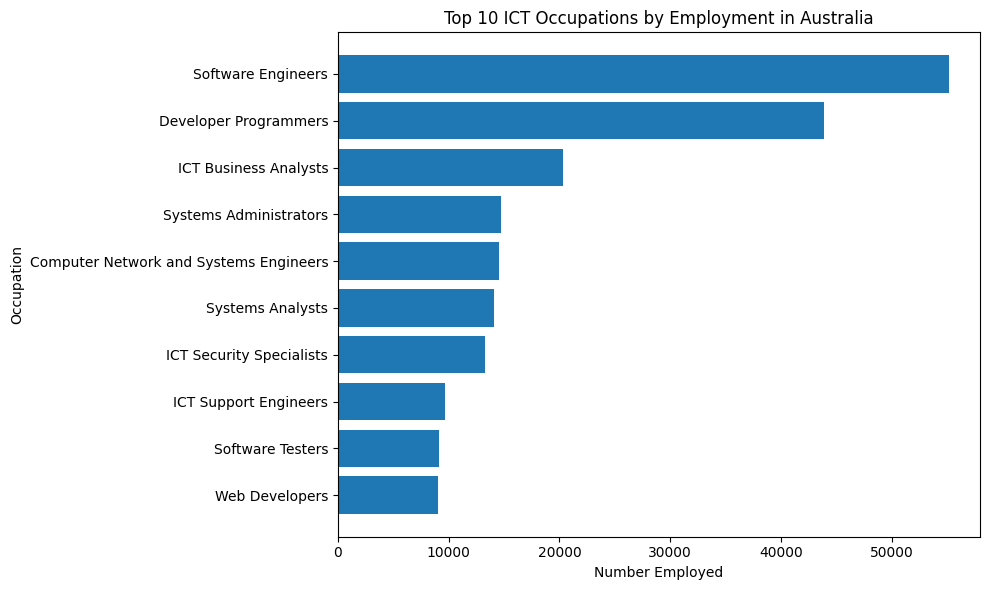

In [12]:
import matplotlib.pyplot as plt

top_10 = top_employment.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Occupation"],
    top_10["Employed"]
)

plt.xlabel("Number Employed")
plt.ylabel("Occupation")
plt.title("Top 10 ICT Occupations by Employment in Australia")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
top_growth = ict_df.sort_values(
    by="Annual employment growth",
    ascending=False
)

top_growth[
    ["Occupation", "Annual employment growth"]
].head(10)

,Occupation,Annual employment growth
679,ICT Business Analysts,NaN
680,Systems Analysts,NaN
681,Game and Multimedia Developers,NaN
682,Web Developers,NaN
683,Analyst Programmers,NaN
684,Developer Programmers,NaN
685,Software Engineers,NaN
686,Software Testers,NaN
687,Other Software and Applications Programmers,NaN
688,Database Administrators,NaN


In [14]:
ict_df[
    ["Occupation", "Median weekly earnings ($)"]
]

,Occupation,Median weekly earnings ($)
679,ICT Business Analysts,NaN
680,Systems Analysts,NaN
681,Game and Multimedia Developers,NaN
682,Web Developers,NaN
683,Analyst Programmers,NaN
684,Developer Programmers,NaN
685,Software Engineers,NaN
686,Software Testers,NaN
687,Other Software and Applications Programmers,NaN
688,Database Administrators,NaN


In [15]:
ict_groups = df[
    (df["ANZSCO Code"].str.startswith("26")) &
    (df["ANZSCO Code"].str.len() == 4)
].copy()

ict_groups[
    ["ANZSCO Code", "Occupation", "Employed",
     "Median weekly earnings ($)", "Annual employment growth"]
]

,ANZSCO Code,Occupation,Employed,Median weekly earnings ($),Annual employment growth
122,2611,ICT Business and Systems Analysts,51000,2697.0,800.0
123,2612,Multimedia Specialists and Web Developers,12400,2476.0,-600.0
124,2613,Software and Applications Programmers,203200,2537.0,13700.0
125,2621,"Database and Systems Administrators, and ICT S...",72600,2461.0,3300.0
126,2631,Computer Network Professionals,48600,2309.0,2600.0
127,2632,ICT Support and Test Engineers,14800,2115.0,200.0
128,2633,Telecommunications Engineering Professionals,13700,2797.0,-300.0


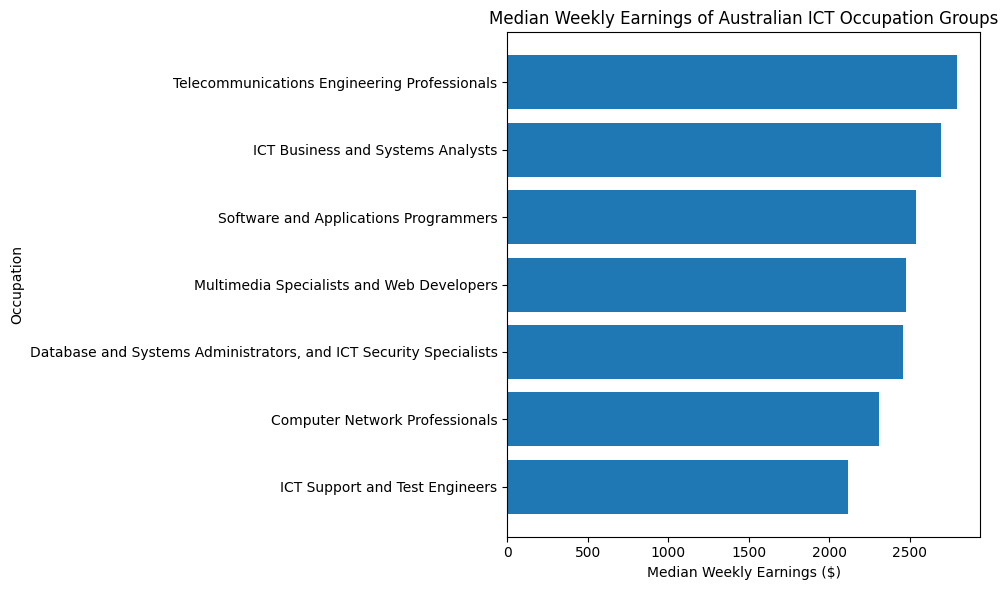

In [16]:
import matplotlib.pyplot as plt

earnings = ict_groups.sort_values(
    by="Median weekly earnings ($)",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    earnings["Occupation"],
    earnings["Median weekly earnings ($)"]
)

plt.xlabel("Median Weekly Earnings ($)")
plt.ylabel("Occupation")
plt.title("Median Weekly Earnings of Australian ICT Occupation Groups")

plt.tight_layout()
plt.show()

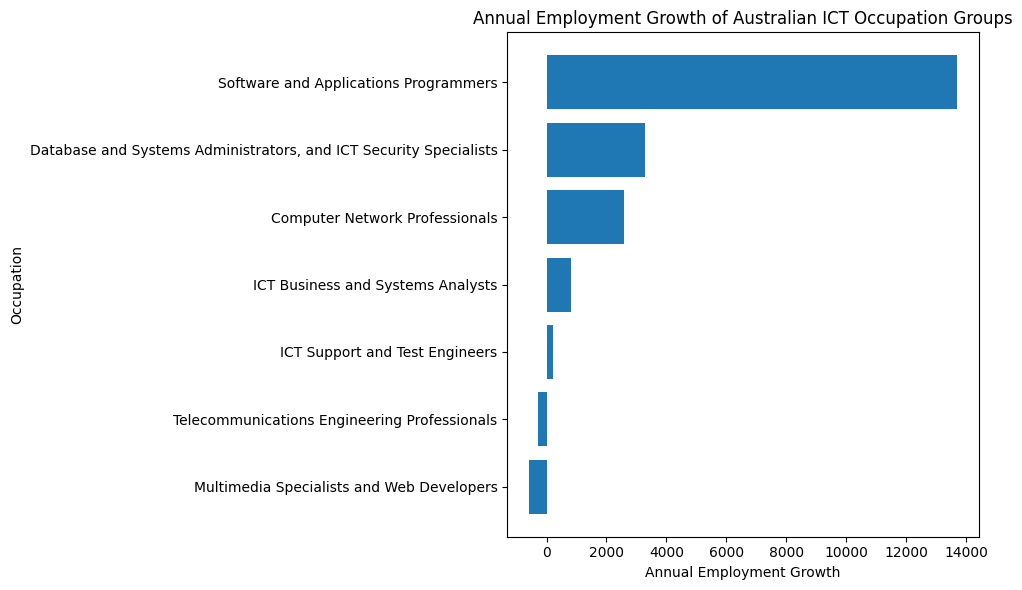

In [17]:
growth = ict_groups.sort_values(
    by="Annual employment growth",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    growth["Occupation"],
    growth["Annual employment growth"]
)

plt.xlabel("Annual Employment Growth")
plt.ylabel("Occupation")
plt.title("Annual Employment Growth of Australian ICT Occupation Groups")

plt.tight_layout()
plt.show()

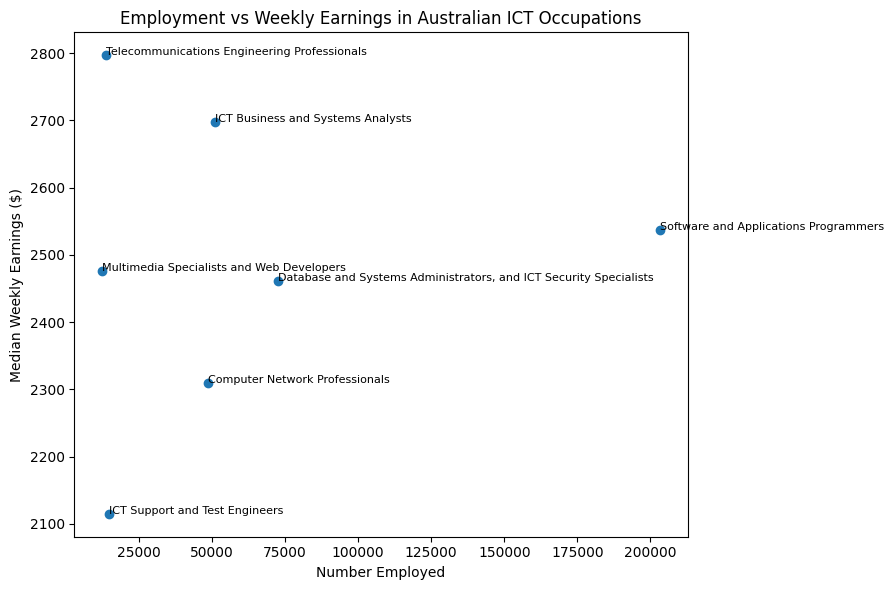

In [18]:
plt.figure(figsize=(9, 6))

plt.scatter(
    ict_groups["Employed"],
    ict_groups["Median weekly earnings ($)"]
)

for i, row in ict_groups.iterrows():
    plt.annotate(
        row["Occupation"],
        (row["Employed"], row["Median weekly earnings ($)"]),
        fontsize=8
    )

plt.xlabel("Number Employed")
plt.ylabel("Median Weekly Earnings ($)")
plt.title("Employment vs Weekly Earnings in Australian ICT Occupations")

plt.tight_layout()
plt.show()

## Key Findings

- Software and Applications Programmers have the largest employment level among the ICT occupation groups analysed.
- Telecommunications Engineering Professionals have the highest median weekly earnings.
- ICT Business and Systems Analysts combine relatively high earnings with substantial employment.
- Software and Applications Programmers show particularly strong annual employment growth.
- Overall, the data shows that employment size, earnings and employment growth vary considerably across ICT occupation groups.